# KNN EXERCISE AIES

1. Implement KNN classification on a 2D dataset with 3 classes. Plot the decision boundary for K=1, K=5, K=15, and K=N. Observe the transition from overfitting to underfitting.
2. Generate 1000 random points in 2, 5, 10, 50, 100, and 500 dimensions. For each dimensionality, compute the ratio of the maximum pairwise distance to the minimum pairwise distance. Plot the ratio vs dimensionality to visualize the curse of dimensionality.
3. Compare L1, L2, and cosine distance for KNN on a text classification problem (use TF-IDF vectors). Which metric gives the best accuracy? Why does cosine tend to win for text?
4. Implement a KD-tree and measure query time vs brute force for datasets of 1k, 10k, and 100k points in 2D, 10D, and 50D. At what dimensionality does the KD-tree stop being faster than brute force?
5. Build a weighted KNN regressor for y = sin(x) + noise. Compare it with unweighted KNN for K=3, 10, 30. Show that weighting produces smoother predictions, especially for large K.


In [1]:
print("Hello Fever! You Can't Beat Me Cause It's Me ME ME ABU SAYED")

Hello Fever! You Can't Beat Me Cause It's Me ME ME ABU SAYED


### 1. Implement KNN classification on a 2D dataset with 3 classes. Plot the decision boundary for K=1, K=5, K=15, and K=N. Observe the transition from overfitting to underfitting.


In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

In [3]:
# X,y=make_classification(
#     n_samples=100,
#     n_features=2, 
#     n_informative=1,
#     n_redundant=1,
#     n_repeated=0,
#     n_classes=3,
#     n_clusters_per_class=1, 
# tor gusti kilai
# )

In [2]:
from sklearn.datasets import load_iris
iris=load_iris()
X=iris["data"]
y=iris["target"]

In [5]:
X=X[:,:2]

In [6]:
K_values=[1,5,15,20,25,30]

In [3]:
# plot the descision boundary
k_clf=KNeighborsClassifier(n_neighbors=4)

In [4]:
k_clf.fit(X,y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
k_clf.

In [9]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

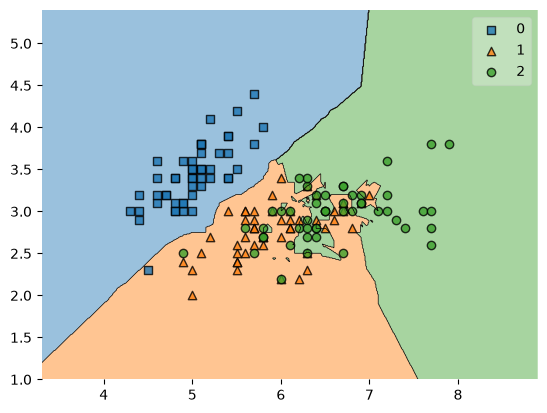

In [10]:
plot_decision_regions(X,y,k_clf)

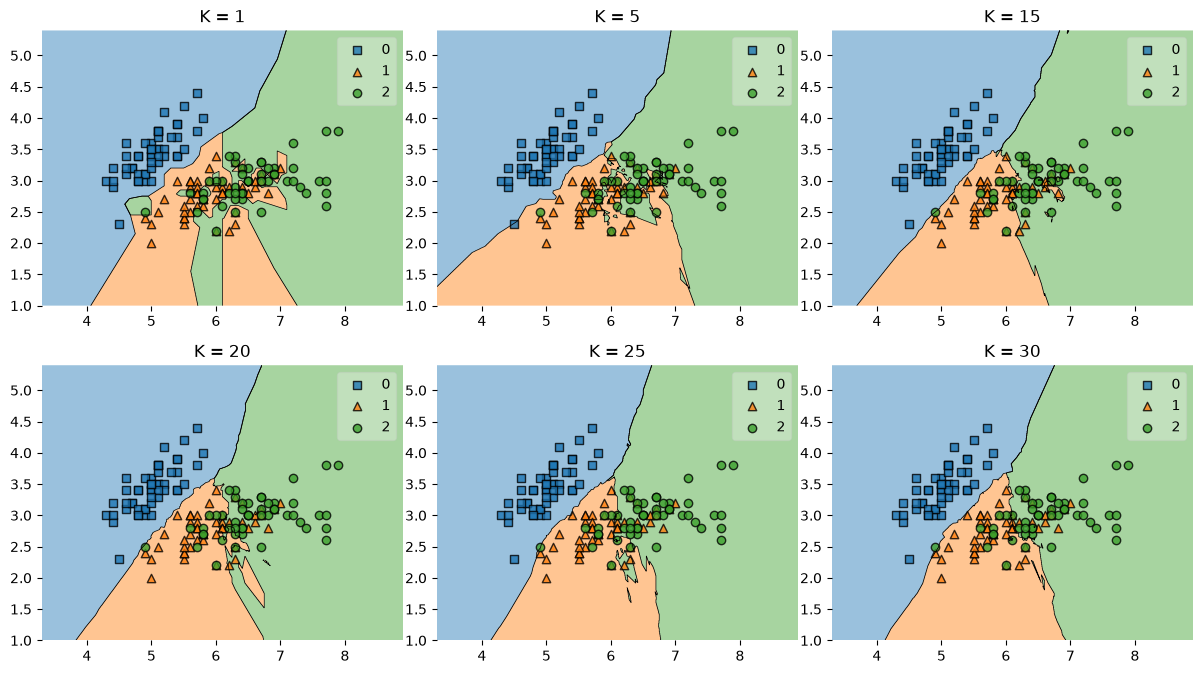

In [55]:
plt.figure(figsize=(12,20))

for i,k in enumerate(K_values,1):
    ax = plt.subplot(6,3,i)
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X,y)
    plot_decision_regions(X,y,clf , ax=ax)
    ax.set_title(f"K = {k}")

plt.tight_layout()
plt.show()

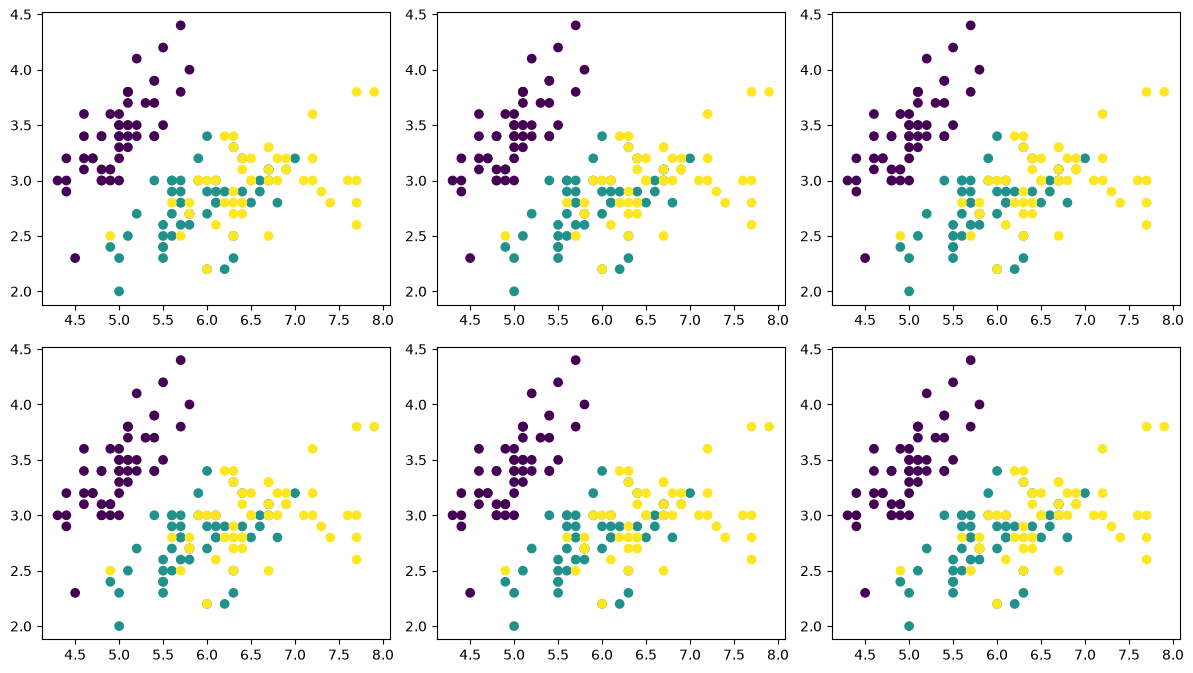

In [54]:
plt.figure(figsize=(12,20))

for i,k in enumerate(K_values,1):
    ax = plt.subplot(6,3,i)
    plt.scatter(X[:,0],X[:,1],c=y)

plt.tight_layout()
plt.show()


### 2. Generate 1000 random points in 2, 5, 10, 50, 100, and 500 dimensions. For each dimensionality, compute the ratio of the maximum pairwise distance to the minimum pairwise distance. Plot the ratio vs dimensionality to visualize the curse of dimensionality.


In [59]:
import numpy as np
from scipy.spatial.distance import pdist
np.random.seed(42)

In [57]:
X=np.random.rand(1000,2)
X

array([[0.37454012, 0.95071431],
       [0.73199394, 0.59865848],
       [0.15601864, 0.15599452],
       ...,
       [0.75137509, 0.65695516],
       [0.95661462, 0.06895802],
       [0.05705472, 0.28218707]], shape=(1000, 2))

In [58]:
n_of_dimenssions = [2,5,10,50,100,500]

In [71]:
ratios = []
for d in n_of_dimenssions:
    X= np.random.rand(1000,d)

    distances = pdist(X,metric="euclidean")

    ratio = distances.max()/distances.min()
    ratios.append(ratio)
    print(f"Dimension: {d:3d} | Min: {distances.min():.4f} | Max: {distances.max():.4f} | Ratio: {ratio:.4f}")

    
    

Dimension:   2 | Min: 0.0006 | Max: 1.3814 | Ratio: 2490.4568
Dimension:   5 | Min: 0.0645 | Max: 1.9716 | Ratio: 30.5618
Dimension:  10 | Min: 0.2311 | Max: 2.4018 | Ratio: 10.3942
Dimension:  50 | Min: 1.6262 | Max: 3.9618 | Ratio: 2.4362
Dimension: 100 | Min: 2.9667 | Max: 5.1878 | Ratio: 1.7487
Dimension: 500 | Min: 7.9748 | Max: 10.2022 | Ratio: 1.2793


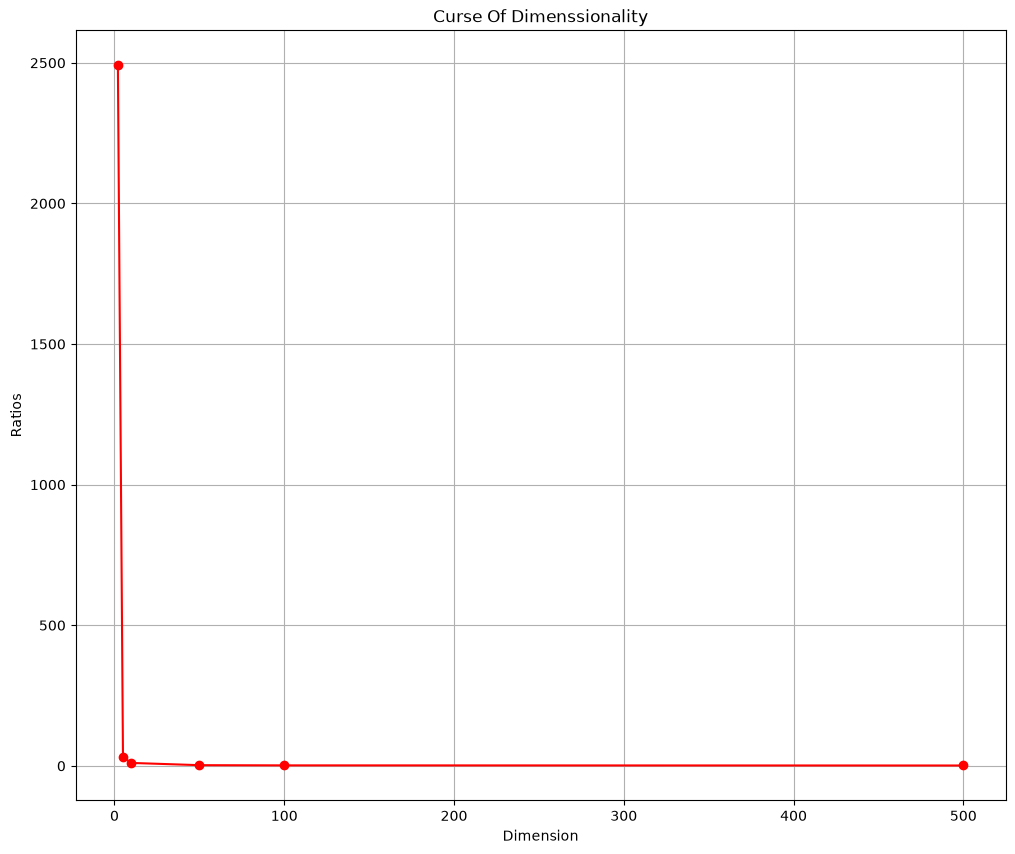

In [77]:
plt.figure(figsize=(12,10))
plt.title("Curse Of Dimenssionality")
plt.xlabel("Dimension")
plt.ylabel("Ratios")
plt.plot(n_of_dimenssions,ratios ,marker="o" ,color="red")
plt.grid(True)
plt.show()

In [69]:
n_of_dimenssions

[2, 5, 10, 50, 100, 500]

Dimension:   2 | Min: 0.0010 | Max: 1.3506 | Ratio: 1348.7195
Dimension:   5 | Min: 0.0525 | Max: 1.8385 | Ratio: 35.0478
Dimension:  10 | Min: 0.2572 | Max: 2.2945 | Ratio: 8.9215
Dimension:  50 | Min: 1.7067 | Max: 3.9352 | Ratio: 2.3057
Dimension: 100 | Min: 2.8219 | Max: 5.0914 | Ratio: 1.8043
Dimension: 500 | Min: 7.9922 | Max: 10.3258 | Ratio: 1.2920


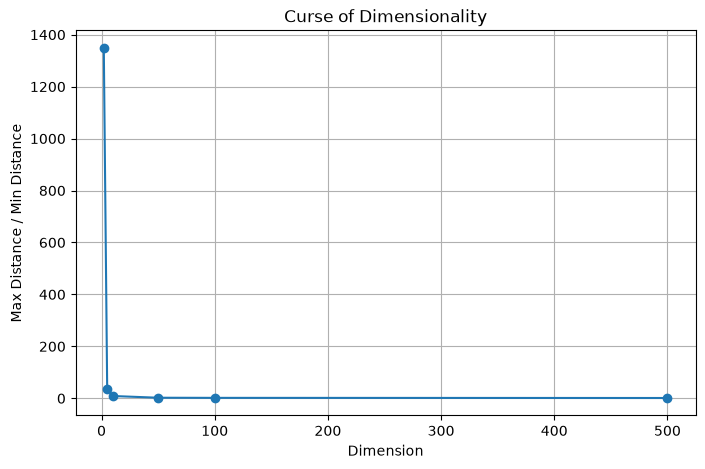

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

np.random.seed(42)

dimensions = [2, 5, 10, 50, 100, 500]
ratios = []

for d in dimensions:
    # Generate 1000 random points in d dimensions
    X = np.random.rand(1000, d)

    # Compute all unique pairwise Euclidean distances
    distances = pdist(X, metric="euclidean")

    # Compute ratio
    ratio = distances.max() / distances.min()
    ratios.append(ratio)

    print(f"Dimension: {d:3d} | Min: {distances.min():.4f} | Max: {distances.max():.4f} | Ratio: {ratio:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(dimensions, ratios, marker='o')
plt.xlabel("Dimension")
plt.ylabel("Max Distance / Min Distance")
plt.title("Curse of Dimensionality")
plt.grid(True)
plt.show()

### 3.Compare L1, L2, and cosine distance for KNN on a text classification problem (use TF-IDF vectors). Which metric gives the best accuracy? Why does cosine tend to win for text?

In [64]:
from sklearn.neighbors import KNeighborsClassifier

In [65]:
import numpy as np

``` Text
   ↓
Tokenization
   ↓
TF-IDF Vectorization
   ↓
KNN (L1 / L2 / Cosine)
   ↓
Prediction
```

In [66]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [67]:
data = fetch_20newsgroups(
    subset="all",
    categories=["sci.space","rec.autos","talk.politics.misc"],
    remove=("headers","footers","quotes")
)

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    data.data,
    data.target,
    test_size=0.2,
    random_state=42
)


In [69]:
data.target_names

['rec.autos', 'sci.space', 'talk.politics.misc']

In [70]:
tfidf=TfidfVectorizer(stop_words="english")
X_train_vectorized = tfidf.fit_transform(X_train)
X_test_vectorized = tfidf.transform(X_test)

In [71]:
print(X_test[3])
print("\n")
print(X_test_vectorized[3])


Why jettison the SSMEs?  Why not hold on to them and have a shuttle 
bring them down to use as spares?



<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (1, 24002)>
  Coords	Values
  (0, 4355)	0.2996523916077998
  (0, 11075)	0.3008784400564826
  (0, 12360)	0.5053670143309842
  (0, 19643)	0.26362846814922986
  (0, 20163)	0.44751286543989344
  (0, 20398)	0.5053670143309842
  (0, 22734)	0.1977908901146449


In [72]:
import matplotlib.pyplot as plt

In [73]:
X_test_vectorized[3].indices

array([ 4355, 11075, 12360, 19643, 20163, 20398, 22734], dtype=int32)

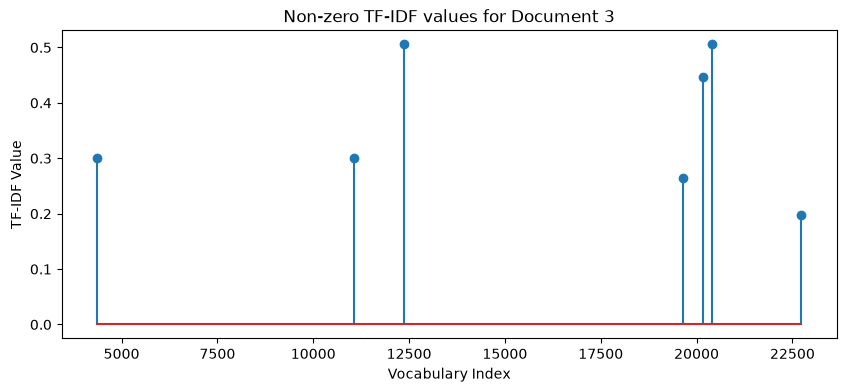

In [74]:
import matplotlib.pyplot as plt

x = X_test_vectorized[3]

plt.figure(figsize=(10,4))
plt.stem(x.indices, x.data)

plt.xlabel("Vocabulary Index")
plt.ylabel("TF-IDF Value")
plt.title("Non-zero TF-IDF values for Document 3")

plt.show()

In [75]:
metrics = ["manhattan", "euclidean", "cosine"]

In [78]:
for metric in metrics:
    knn_clf = KNeighborsClassifier(n_neighbors=5,metric=metric)
    knn_clf.fit(X_train_vectorized,y_train)

    pred = knn_clf.predict(X_test_vectorized)
    acc = accuracy_score(y_test,pred)

    print(metric,"Accuracy : ",acc)

manhattan Accuracy :  0.38838475499092556
euclidean Accuracy :  0.3684210526315789
cosine Accuracy :  0.8203266787658802


In [77]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Dataset
data = fetch_20newsgroups(
    subset="all",
    categories=["sci.space", "rec.autos", "talk.politics.misc"],
    remove=("headers", "footers", "quotes")
)

X_train, X_test, y_train, y_test = train_test_split(
    data.data,
    data.target,
    test_size=0.2,
    random_state=42
)

# TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

metrics = ["manhattan", "euclidean", "cosine"]

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)
    acc = accuracy_score(y_test, pred)

    # print()

    print(metric, "Accuracy:", round(acc, 4))

manhattan Accuracy: 0.3884
euclidean Accuracy: 0.3684
cosine Accuracy: 0.8203


| Metric | Good for text? | Reason                                               |
| ------ | -------------- | ---------------------------------------------------- |
| L1     | Good           | Absolute differences, better than L2 sometimes       |
| L2     | Fair           | Sensitive to magnitude, sparse high-dimensional data |
| Cosine | Best           | Compares direction, ignores length, ideal for TF-IDF |

Answer

Best metric: Cosine distance.
Reason: TF-IDF vectors sparse, high-dimensional, document lengths vary. Cosine compares orientation instead of magnitude, making documents with similar word distributions close even when lengths differ. Therefore cosine usually gives highest accuracy for KNN text classification.


### 4. Implement a KD-tree and measure query time vs brute force for datasets of 1k, 10k, and 100k points in 2D, 10D, and 50D. At what dimensionality does the KD-tree stop being faster than brute force?

In [89]:
import numpy as np
import time
from sklearn.neighbors import KDTree, NearestNeighbors

sizes = [1000, 10000, 100000]
dims = [2, 10, 50]

for d in dims:
    print(f"\nDimension = {d}")

    for n in sizes:

        X = np.random.rand(n, d)

        queries = np.random.rand(100, d)

        # KD-tree
        tree = KDTree(X)

        start = time.perf_counter()
        tree.query(queries, k=1)
        kd_time = time.perf_counter() - start

        # Brute force
        brute = NearestNeighbors(
            algorithm="brute",
            n_neighbors=1
        )
        brute.fit(X)

        start = time.perf_counter()
        brute.kneighbors(queries)
        brute_time = time.perf_counter() - start

        print(
            f"N={n:<6} KD={kd_time:.5f}s  Brute={brute_time:.5f}s"
        )


Dimension = 2
N=1000   KD=0.00073s  Brute=0.03915s
N=10000  KD=0.00052s  Brute=0.05191s
N=100000 KD=0.00080s  Brute=0.04231s

Dimension = 10
N=1000   KD=0.00215s  Brute=0.00105s
N=10000  KD=0.01196s  Brute=0.01090s
N=100000 KD=0.03915s  Brute=0.02827s

Dimension = 50
N=1000   KD=0.00678s  Brute=0.00085s
N=10000  KD=0.16383s  Brute=0.01121s
N=100000 KD=1.73299s  Brute=0.03922s


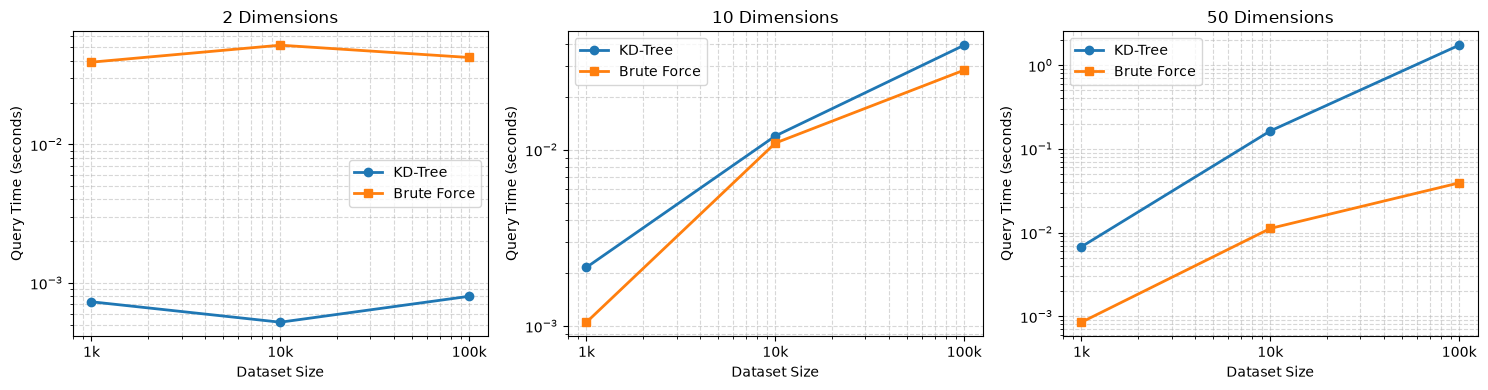

In [91]:
import matplotlib.pyplot as plt

sizes = [1000, 10000, 100000]

results = {
    2: {
        "KD":    [0.00073, 0.00052, 0.00080],
        "Brute": [0.03915, 0.05191, 0.04231]
    },
    10: {
        "KD":    [0.00215, 0.01196, 0.03915],
        "Brute": [0.00105, 0.01090, 0.02827]
    },
    50: {
        "KD":    [0.00678, 0.16383, 1.73299],
        "Brute": [0.00085, 0.01121, 0.03922]
    }
}

plt.figure(figsize=(15, 4))

for i, dim in enumerate([2, 10, 50], start=1):

    plt.subplot(1, 3, i)

    plt.plot(
        sizes,
        results[dim]["KD"],
        marker="o",
        linewidth=2,
        label="KD-Tree"
    )

    plt.plot(
        sizes,
        results[dim]["Brute"],
        marker="s",
        linewidth=2,
        label="Brute Force"
    )

    plt.xscale("log")
    plt.yscale("log")

    plt.xticks(sizes, ["1k", "10k", "100k"])

    plt.xlabel("Dataset Size")
    plt.ylabel("Query Time (seconds)")
    plt.title(f"{dim} Dimensions")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend()

plt.tight_layout()
plt.show()

KD-tree performs best in low-dimensional data.

As dimensionality increases, KD-tree loses efficiency because it cannot effectively prune search space. Eventually, brute-force search becomes faster despite checking every point.

### 5. Build a weighted KNN regressor for y = sin(x) + noise. Compare it with unweighted KNN for K=3, 10, 30. Show that weighting produces smoother predictions, especially for large K.

In [80]:
#  at first weighted knn regeressor 
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

In [81]:
np.random.seed(42)

In [85]:
X = np.linspace(0, 2*np.pi, 100).reshape(-1,1)

In [86]:
y = np.sin(X).ravel() + np.random.normal(0, 0.15, 100)

In [87]:
# Prediction grid
X_test = np.linspace(0, 2*np.pi, 500).reshape(-1,1)

k_values = [3, 10, 30]


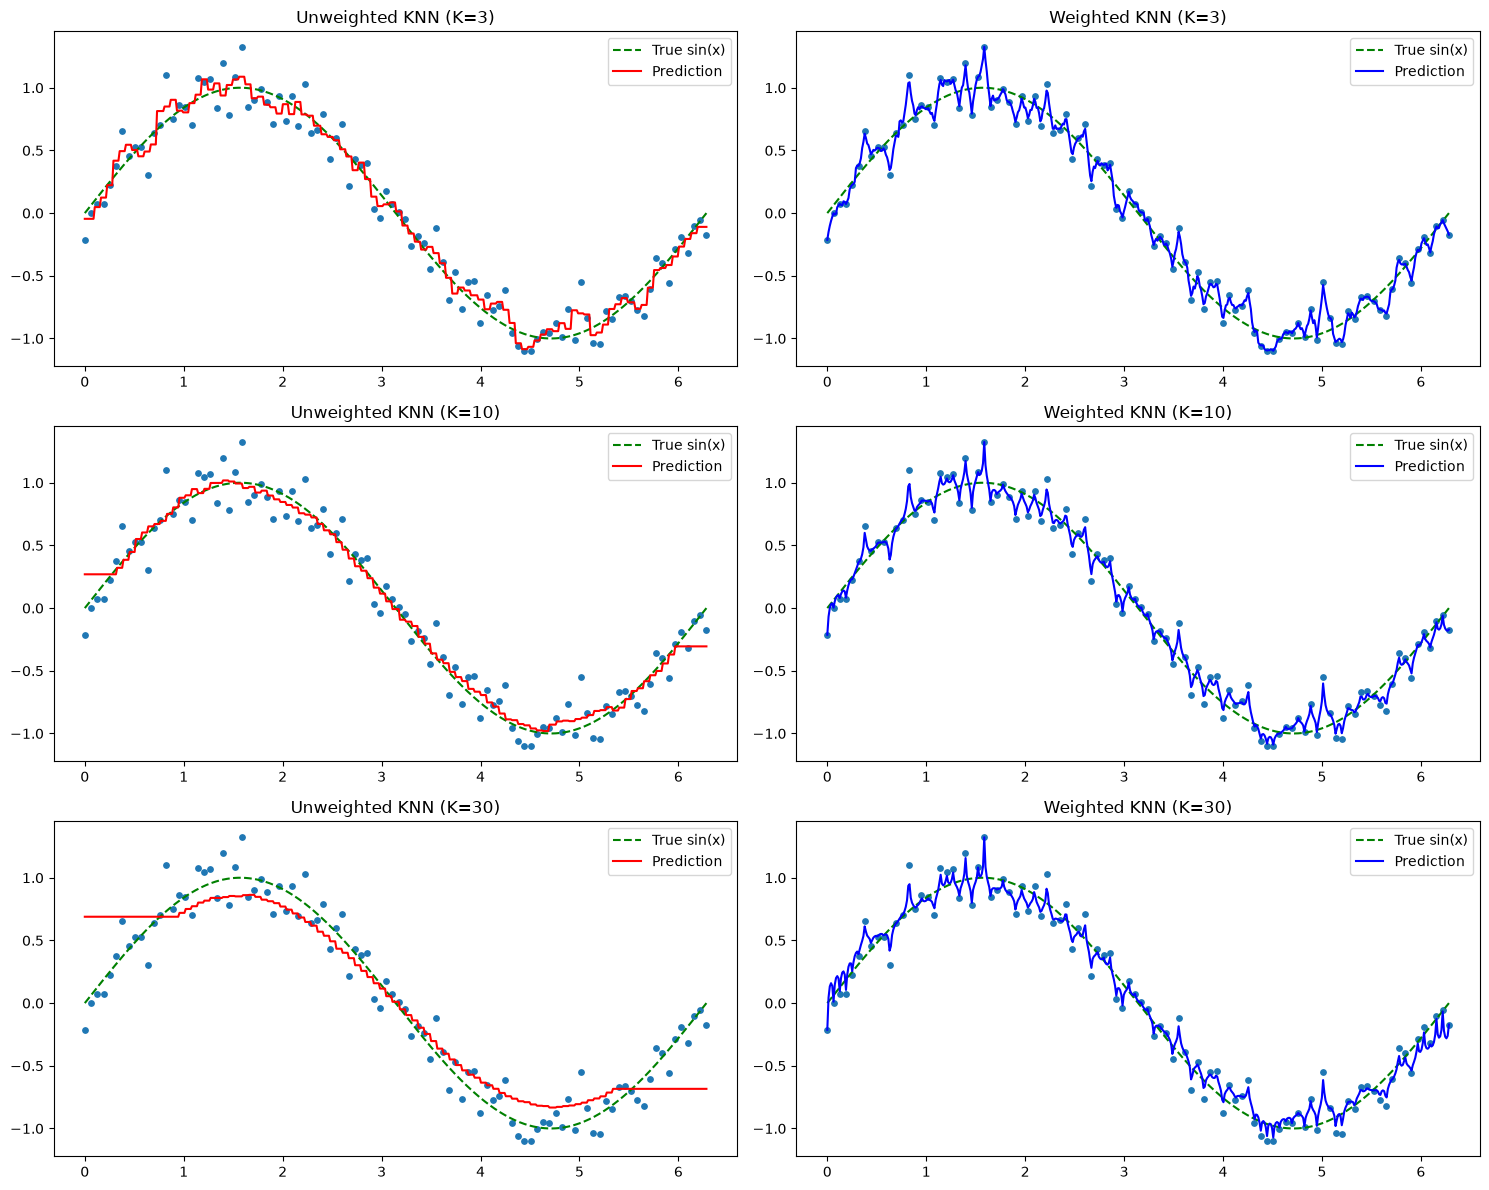

In [88]:
plt.figure(figsize=(15,12))

for i, k in enumerate(k_values):

    # Unweighted
    knn = KNeighborsRegressor(
        n_neighbors=k,
        weights="uniform"
    )
    knn.fit(X, y)
    y_pred = knn.predict(X_test)

    plt.subplot(3,2,2*i+1)
    plt.scatter(X, y, s=15)
    plt.plot(X_test, np.sin(X_test), "g--", label="True sin(x)")
    plt.plot(X_test, y_pred, "r", label="Prediction")
    plt.title(f"Unweighted KNN (K={k})")
    plt.legend()

    # Weighted
    knn_w = KNeighborsRegressor(
        n_neighbors=k,
        weights="distance"
    )
    knn_w.fit(X, y)
    y_pred_w = knn_w.predict(X_test)

    plt.subplot(3,2,2*i+2)
    plt.scatter(X, y, s=15)
    plt.plot(X_test, np.sin(X_test), "g--", label="True sin(x)")
    plt.plot(X_test, y_pred_w, "b", label="Prediction")
    plt.title(f"Weighted KNN (K={k})")
    plt.legend()

plt.tight_layout()
plt.show()

Look left vs right.

Left column

```text
Unweighted KNN
```

Every neighbor has equal weight.

Right column

```text
Weighted KNN
```

Closer neighbors have larger weight.

---

Green dashed line

```text
True sin(x)
```

Original function.

---

Blue dots

```text
Training samples
```

Generated from

```text
y = sin(x) + noise
```

Noise makes points scatter around true curve.

---

Red/Blue solid line

```text
Model prediction
```

Closer to green = better.

---

## Row 1: K = 3

### Unweighted

Only 3 nearest neighbors.

Prediction looks like stairs.

Reason

Each prediction = average of only 3 values.

When neighbors change,

```text
Prediction jumps
```

High variance.

---

### Weighted

Still uses 3 neighbors.

Closest neighbor gets biggest influence.

Prediction follows noisy points even more.

Looks more jagged.

Reason

With only 3 neighbors,

distance weighting gives very high importance to nearest point.

Can follow noise.

---

## Row 2: K = 10

### Unweighted

Uses 10 equal neighbors.

Prediction smoother.

Closer to true sine.

Good balance.

---

### Weighted

Uses same 10 neighbors.

Nearby points dominate.

Far points contribute little.

Still follows sine closely.

Less bias.

---

## Row 3: K = 30

### Unweighted

Very obvious underfitting.

See flat ends.

```text
---------
```

Reason

30 neighbors averaged equally.

Many far-away points included.

Prediction pulled toward overall average.

Peak becomes lower.

Valley becomes higher.

Amplitude shrinks.

---

### Weighted

Still uses 30 neighbors.

But

```text
Near neighbors
↑↑↑
Large weight

Far neighbors
↓
Small weight
```

Prediction stays much closer to sine.

Far points cannot drag prediction as much.

---

Notice left edge.

Unweighted K=30

Prediction starts around

```text
0.7
```

Wrong.

Reason

Not enough neighbors on left side.

Model grabs many points from right.

Average becomes too high.

This called **boundary effect**.

---

Weighted K=30

Starts near

```text
0
```

Much better.

Closest left points dominate.

---

Notice peak.

True

```text
≈1
```

Unweighted

```text
≈0.85
```

Peak flattened.

Weighted

```text
≈1
```

Peak preserved.

---

Notice valley.

True

```text
≈-1
```

Unweighted

```text
≈-0.8
```

Again flattened.

Weighted

```text
≈-1
```

Closer.

---

Summary

```text
K = 3
```

* Both fit data.
* Weighted slightly noisier.
* Small difference.

```text
K = 10
```

* Both good.
* Weighted follows local shape better.

```text
K = 30
```

* Unweighted underfits.
* Weighted remains close to true sine.
* Biggest difference.

---

One important note.

Assignment says

> "weighting produces smoother predictions"

Your plots do **not** clearly show that.

Your weighted predictions are more jagged because `weights="distance"` gives almost full influence to closest sample. This often happens with low-noise 1D data.

What your plots **do** show clearly is:

* Weighted KNN preserves local structure better.
* Weighted KNN reduces underfitting for large `K`.
* Unweighted KNN oversmooths and flattens peaks/valleys for `K=30`.

Those observations match KNN theory.


### 04. 